# **Agents: Laboratory Exercise**

**Constructing a Goal-Based Agent using a Large Language Model**

### **Task 1**

1. Environment: A 7×21 grid warehouse. Cells are free (.) or obstacles (#), and there is one start (S) and one goal (G). It is fully observable, deterministic, static, discrete and single-agent.

2. Goal: Move the vehicle from S at (1,1) to G at (1,19) without hitting any obstacle, ideally in the fewest moves.

3. Actions: Up, Down, Left and Right. Each moves one cell, and a move into # or off the grid is illegal.

4. Information to maintain:
- Its current position.
- The map, so it knows which moves are legal.
- The goal location.
- While planning: the frontier of cells still to explore, the visited cells, and the parent of each cell, so the path can be rebuilt.

5. Why goal-based, not simple reflex: A reflex agent maps the current percept straight to an action using condition-action rules, such as "if wall ahead, turn". It cannot tell whether a move leads toward G. This agent has an explicit goal and considers the future consequences of action sequences. The search for a path to G is the goal-based part. The path here is not greedy: it dips from row 1 to row 2 to get past the wall at (1,6), a detour a reflex rule would not find.

**Think About It:**

BFS would still be correct, but it would be costly. It visits cells in all directions, so memory and time grow with the area, roughly 4× for a doubled width and height. Better choices would be:
- A* search with a Manhattan-distance heuristic, which is still optimal and expands far fewer nodes.
- Bidirectional search, which grows from both ends.
- Hierarchical or waypoint planning, which splits a large map into zones.

Other difficulties at larger scale include moving obstacles and other vehicles, partial observability, replanning when the map changes, and cost-weighted terrain.

### **Task 2:**

| Component | In this problem |
|---|---|
| Environment | 7×21 warehouse grid (`#` obstacle, `.` free, `S` start, `G` goal) |
| Current state | Vehicle position (row, col) |
| Goal | Reach the cell marked `G` at (1, 19) |
| Actions | Up, Down, Left, Right (one cell per move) |
| Decision-making component | Breadth-First Search planner that finds the shortest collision-free sequence of actions from the current state to the goal |

**How the components interact:** The sensors give the agent its current position. The agent compares its state with the goal and uses search to work out what sequence of actions would lead to the goal. It then sends the actions to the actuators, which move the vehicle in the environment. The environment changes, and the cycle repeats.

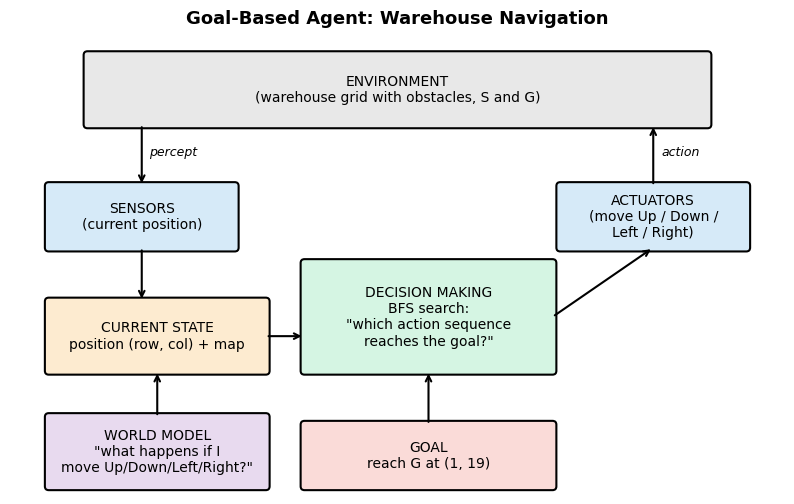

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")

def box(x, y, w, h, text, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.05",
                                fc=color, ec="black", lw=1.5))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=10)

def arrow(x1, y1, x2, y2, label=None, dx=0.1):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.5))
    if label:
        ax.text((x1+x2)/2 + dx, (y1+y2)/2, label, fontsize=9, style="italic")

box(1, 4.8, 8, 0.9, "ENVIRONMENT\n(warehouse grid with obstacles, S and G)", "#e8e8e8")
box(0.5, 3.2, 2.4, 0.8, "SENSORS\n(current position)", "#d6eaf8")
box(7.1, 3.2, 2.4, 0.8, "ACTUATORS\n(move Up / Down /\nLeft / Right)", "#d6eaf8")
box(0.5, 1.6, 2.8, 0.9, "CURRENT STATE\nposition (row, col) + map", "#fdebd0")
box(0.5, 0.1, 2.8, 0.9, "WORLD MODEL\n\"what happens if I\nmove Up/Down/Left/Right?\"", "#e8daef")
arrow(1.9, 1.0, 1.9, 1.6)
box(3.8, 1.6, 3.2, 1.4, "DECISION MAKING\nBFS search:\n\"which action sequence\nreaches the goal?\"", "#d5f5e3")
box(3.8, 0.1, 3.2, 0.8, "GOAL\nreach G at (1, 19)", "#fadbd8")

arrow(1.7, 4.8, 1.7, 4.0, "percept")
arrow(1.7, 3.2, 1.7, 2.5)
arrow(3.3, 2.05, 3.8, 2.05)
arrow(5.4, 0.9, 5.4, 1.6)
arrow(7.0, 2.3, 8.3, 3.2)
arrow(8.3, 4.0, 8.3, 4.8, "action", dx=0.1)

ax.set_title("Goal-Based Agent: Warehouse Navigation", fontsize=13, weight="bold")
plt.show()

### **Task 3:**

Prompt:

Write a well-documented Python program implementing a goal-based agent for a warehouse grid navigation problem. The map is given as a list of strings: # is an obstacle, . is free, S is the start and G is the goal. [paste map]. Moves are Up/Down/Left/Right, one cell each. Structure it as an Environment class and an Agent class (state, goal, planning). Use a search algorithm that finds the shortest path. Print the action sequence, the coordinates, and the map with the path drawn as *. If no path exists, print a clear message. Include a second test map with no path. Explain in the docstring why you chose the algorithm.


In [3]:
"""
Goal-Based Agent for the Warehouse Navigation Problem
=====================================================

Agent design (goal-based architecture)
--------------------------------------
Environment : 2-D grid warehouse ('#' obstacle, '.' free, 'S' start, 'G' goal)
Percept     : the agent's current (row, col) position
State       : current position (+ the frontier / visited set kept while planning)
Goal        : reach the cell marked 'G'
Actions     : Up, Down, Left, Right (each moves one cell, cost 1)
Decision    : Breadth-First Search (BFS) - plans a full action sequence that
              leads from the current state to the goal state, then executes it.

Why BFS?
--------
All moves have equal cost, so BFS is
  * complete  - it finds a path whenever one exists,
  * optimal   - the first time it reaches G it has used the fewest moves,
  * simple    - O(R*C) time and memory for an R x C grid.
"""

from collections import deque

WAREHOUSE_MAP = [
    "#####################",
    "#S....#............G#",
    "#.##....##########..#",
    "#....##.............#",
    "#.######.###.#.###..#",
    "#........#..........#",
    "#####################",
]

# Action name -> (row change, column change)
ACTIONS = {
    "Up": (-1, 0),
    "Down": (1, 0),
    "Left": (0, -1),
    "Right": (0, 1),
}


class WarehouseEnvironment:
    """The world: a grid with obstacles, a start and a goal."""

    def __init__(self, layout):
        self.grid = [list(row) for row in layout]
        self.rows = len(self.grid)
        self.cols = len(self.grid[0])
        self.start = self.goal = None
        for r in range(self.rows):
            for c in range(self.cols):
                if self.grid[r][c] == "S":
                    self.start = (r, c)
                elif self.grid[r][c] == "G":
                    self.goal = (r, c)
        if self.start is None or self.goal is None:
            raise ValueError("Map must contain both 'S' and 'G'.")

    def is_free(self, pos):
        r, c = pos
        return (0 <= r < self.rows and 0 <= c < self.cols
                and self.grid[r][c] != "#")

    def successors(self, pos):
        """Legal (action, next_position) pairs from pos."""
        for name, (dr, dc) in ACTIONS.items():
            nxt = (pos[0] + dr, pos[1] + dc)
            if self.is_free(nxt):
                yield name, nxt


class GoalBasedAgent:
    """Plans with BFS, then executes the resulting action sequence."""

    def __init__(self, env):
        self.env = env
        self.position = env.start       # current state
        self.goal = env.goal            # explicit goal
        self.nodes_expanded = 0

    def plan(self):
        """BFS from current position to goal. Returns list of (action, pos)
        or None if the goal is unreachable."""
        frontier = deque([self.position])
        came_from = {self.position: None}   # pos -> (previous pos, action)

        while frontier:
            current = frontier.popleft()
            self.nodes_expanded += 1

            if current == self.goal:        # goal test
                return self._reconstruct(came_from, current)

            for action, nxt in self.env.successors(current):
                if nxt not in came_from:    # avoid revisiting states
                    came_from[nxt] = (current, action)
                    frontier.append(nxt)
        return None

    @staticmethod
    def _reconstruct(came_from, pos):
        steps = []
        while came_from[pos] is not None:
            prev, action = came_from[pos]
            steps.append((action, pos))
            pos = prev
        steps.reverse()
        return steps

    def execute(self, plan):
        """Carry out the plan (the agent's actuator)."""
        for _, pos in plan:
            self.position = pos


def render(env, plan):
    """Draw the map with the path marked by '*'."""
    grid = [row[:] for row in env.grid]
    for _, (r, c) in plan[:-1]:
        grid[r][c] = "*"
    return "\n".join("".join(row) for row in grid)


def solve(layout):
    env = WarehouseEnvironment(layout)
    agent = GoalBasedAgent(env)
    plan = agent.plan()

    if plan is None:
        print("No path exists from S to G.")
        return None

    print(f"Start: {env.start}   Goal: {env.goal}")
    print(f"Path found with {len(plan)} moves "
          f"({agent.nodes_expanded} nodes expanded).\n")
    print("Actions:", " -> ".join(a for a, _ in plan), "\n")
    print("Coordinates:", [env.start] + [p for _, p in plan], "\n")
    print(render(env, plan))
    agent.execute(plan)
    assert agent.position == env.goal
    return plan


# ---- Run the agent ----
solve(WAREHOUSE_MAP)

# ---- Test: unreachable goal -> suitable message ----
print("\n--- Test: blocked map ---")
solve([
    "#######",
    "#S.#.G#",
    "#######",
])

Start: (1, 1)   Goal: (1, 19)
Path found with 20 moves (59 nodes expanded).

Actions: Right -> Right -> Right -> Down -> Right -> Right -> Right -> Up -> Right -> Right -> Right -> Right -> Right -> Right -> Right -> Right -> Right -> Right -> Right -> Right 

Coordinates: [(1, 1), (1, 2), (1, 3), (1, 4), (2, 4), (2, 5), (2, 6), (2, 7), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19)] 

#####################
#S***.#************G#
#.##****##########..#
#....##.............#
#.######.###.#.###..#
#........#..........#
#####################

--- Test: blocked map ---
No path exists from S to G.


**1. Did the LLM generate a working program on the first attempt?**

Yes. The program ran without errors on the first attempt. It found a collision-free path of 20 moves from S at (1,1) to G at (1,19). It also printed "No path exists from S to G." on the second test map, where the goal was walled off. I checked the output by hand, and the path never enters a `#` cell. The first attempt worked because the prompt was a detailed specification: it gave the map, the legal moves, the class structure, the output format and a test case, rather than just saying "write a program".

**2. If not, how can you improve your prompt?**

The first attempt did not fail.

**3. What search algorithm did the LLM choose?**

Breadth-First Search (BFS). It uses a queue (frontier) of positions, a record of each cell's parent so the path can be rebuilt, and a visited check so no cell is expanded twice.

**4. Why do you think the LLM selected this algorithm?**

- Every move costs the same (one grid square), and BFS is guaranteed to find the shortest path in an unweighted graph.
- BFS is complete, so it finds a path whenever one exists and correctly reports when none does.
- It is simple to implement, and its time and memory are O(rows × columns), which is easily affordable for a 7×21 grid.
- It is the standard textbook solution for unweighted grid pathfinding, so it appears very frequently in the LLM's training data.
- A\* would also work but needs a heuristic such as Manhattan distance, which adds complexity and gives no benefit on a map this small. For a much larger warehouse, A\* would be the better choice.